### Simple Linear Regression

In [66]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
#loading dataset into dataframe

df = pd.read_csv("datasets\\height-weight.csv")
df.head()



,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


<Axes: xlabel='Weight', ylabel='Height'>

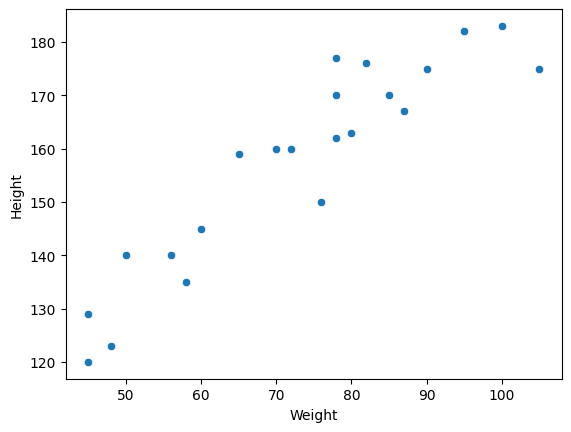

In [35]:
#scatter plot

sns.scatterplot(x='Weight', y='Height', data=df)

In [36]:
#correlation between feature and target feature

df.corr()

#high positive correlation

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


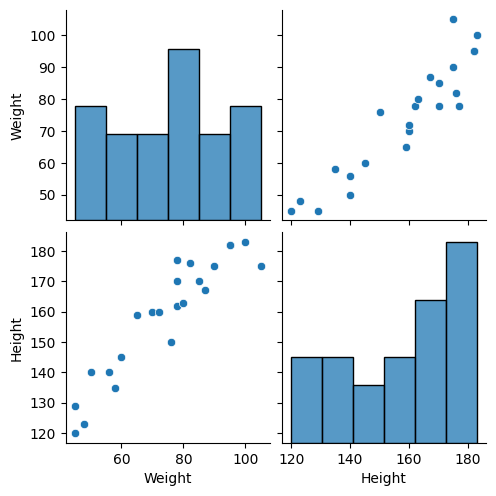

In [37]:
sns.pairplot(df)

In [38]:
#getting independent and dependent features

x = df[['Weight']] #independent feature should be a Dataframe or 2 or more dimensional
y = df['Height'] #dependent feature should be a Series or 1 dimensional

In [39]:
#train_test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(17, 1)
(6, 1)
(17,)
(6,)


In [40]:
x_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [41]:
#Standardization of data

scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [43]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [46]:
#Applying Linear Regression

regressor = LinearRegression()

In [47]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
regressor.coef_

array([17.2982057])

In [51]:
regressor.intercept_

np.float64(156.47058823529412)

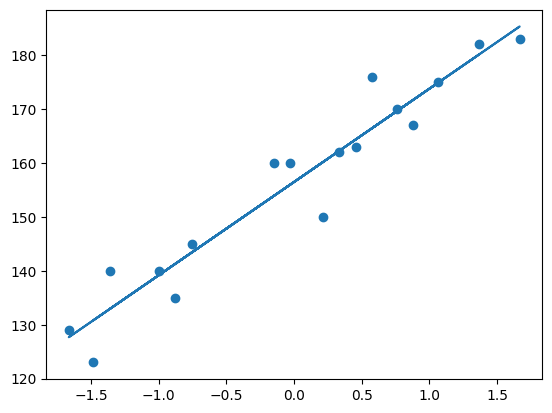

In [57]:
#plotting best fit line on training data

plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train))


In [59]:
#prediction on test data

prediction = regressor.predict(X_test)
prediction 


array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [63]:
#performance metrics

mse = mean_squared_error(y_test, prediction)
mse

114.84069295228699

In [64]:
mae = mean_absolute_error(y_test, prediction)
mae

9.66512588679501

In [65]:
rmse = np.sqrt(mse)
rmse

np.float64(10.716374991212605)

In [67]:
#R-Squared Error (Coefficient of Determination)

score = r2_score(y_test, prediction)
score

0.7360826717981276